# [LAB-09] 2-2. 가정 검정 모듈화 - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 데이터 가져오기

In [2]:
origin = load_data("father-son")
origin.head()

📚 아버지와 아들의 키를 조사한 데이터 (출처: https://www.kaggle.com/datasets/aungdev/pearson-dataset-heights-of-fathers-and-their-sons)


,fheight,sheight
0,65.049,59.778
1,63.251,63.214
2,64.955,63.342
3,65.752,62.792
4,61.137,64.281


## 문제 풀이

### Mission 1. 증거를 수집하라 — 잔차 추출

앞 단원에서 적합한 단순선형회귀 모형으로부터 잔차와 적합값(fitted value)을 추출하라.

In [3]:
# 앞 단원에서 적합한 것과 동일한 단순선형회귀 모형: 아들 키(sheight) ~ 아버지 키(fheight)
fit = my_ols.fit_model(origin, y="sheight")

# 잔차(residual)와 적합값(fitted value) 추출 — 이후 모든 가정 검정의 '증거'가 된다
resid = fit.resid            # 잔차 e = 실제값 - 예측값
fitted = fit.fittedvalues    # 적합값(예측값) ŷ

# 적합값·잔차를 원본 옆에 나란히 정리
evidence = origin.copy()
evidence["적합값"] = fitted
evidence["잔차"] = resid

print(f"표본 수 n = {int(fit.nobs)}")
print(f"잔차 평균 ≈ {resid.mean():.2e}  (0에 수렴 — OLS의 성질)")
print(f"잔차 표준편차 √MSE ≈ {fit.mse_resid ** 0.5:.4f}")
evidence.head()

표본 수 n = 1078
잔차 평균 ≈ 6.04e-15  (0에 수렴 — OLS의 성질)
잔차 표준편차 √MSE ≈ 2.4366


,fheight,sheight,적합값,잔차
0,65.049,59.778,67.328,-7.549
1,63.251,63.214,66.403,-3.189
2,64.955,63.342,67.280,-3.937
3,65.752,62.792,67.690,-4.897
4,61.137,64.281,65.317,-1.036


#### 💡인사이트

- OLS로 적합한 회귀모형에서 잔차의 평균은 항상 0으로 수렴한다(위 출력에서 확인된다).
- 여기서 뽑아낸 잔차와 적합값이 이후 네 가지 가정(선형성·등분산성·정규성·독립성) 검정의 재료가 된다.

### Mission 2. 직선은 옳았는가 — 선형성과 등분산성

잔차 vs 적합값 산점도에서 곡선 패턴이나 깔때기 모양이 보이는지 판단하라.

Breusch-Pagan 검정으로 눈으로 내린 등분산성 판단을 통계적으로 뒷받침하라.

,statistic,p-value,linearity,result
Ramsey RESET,0.032,0.859,True,귀무가설 채택 → 선형성 위배 근거 없음


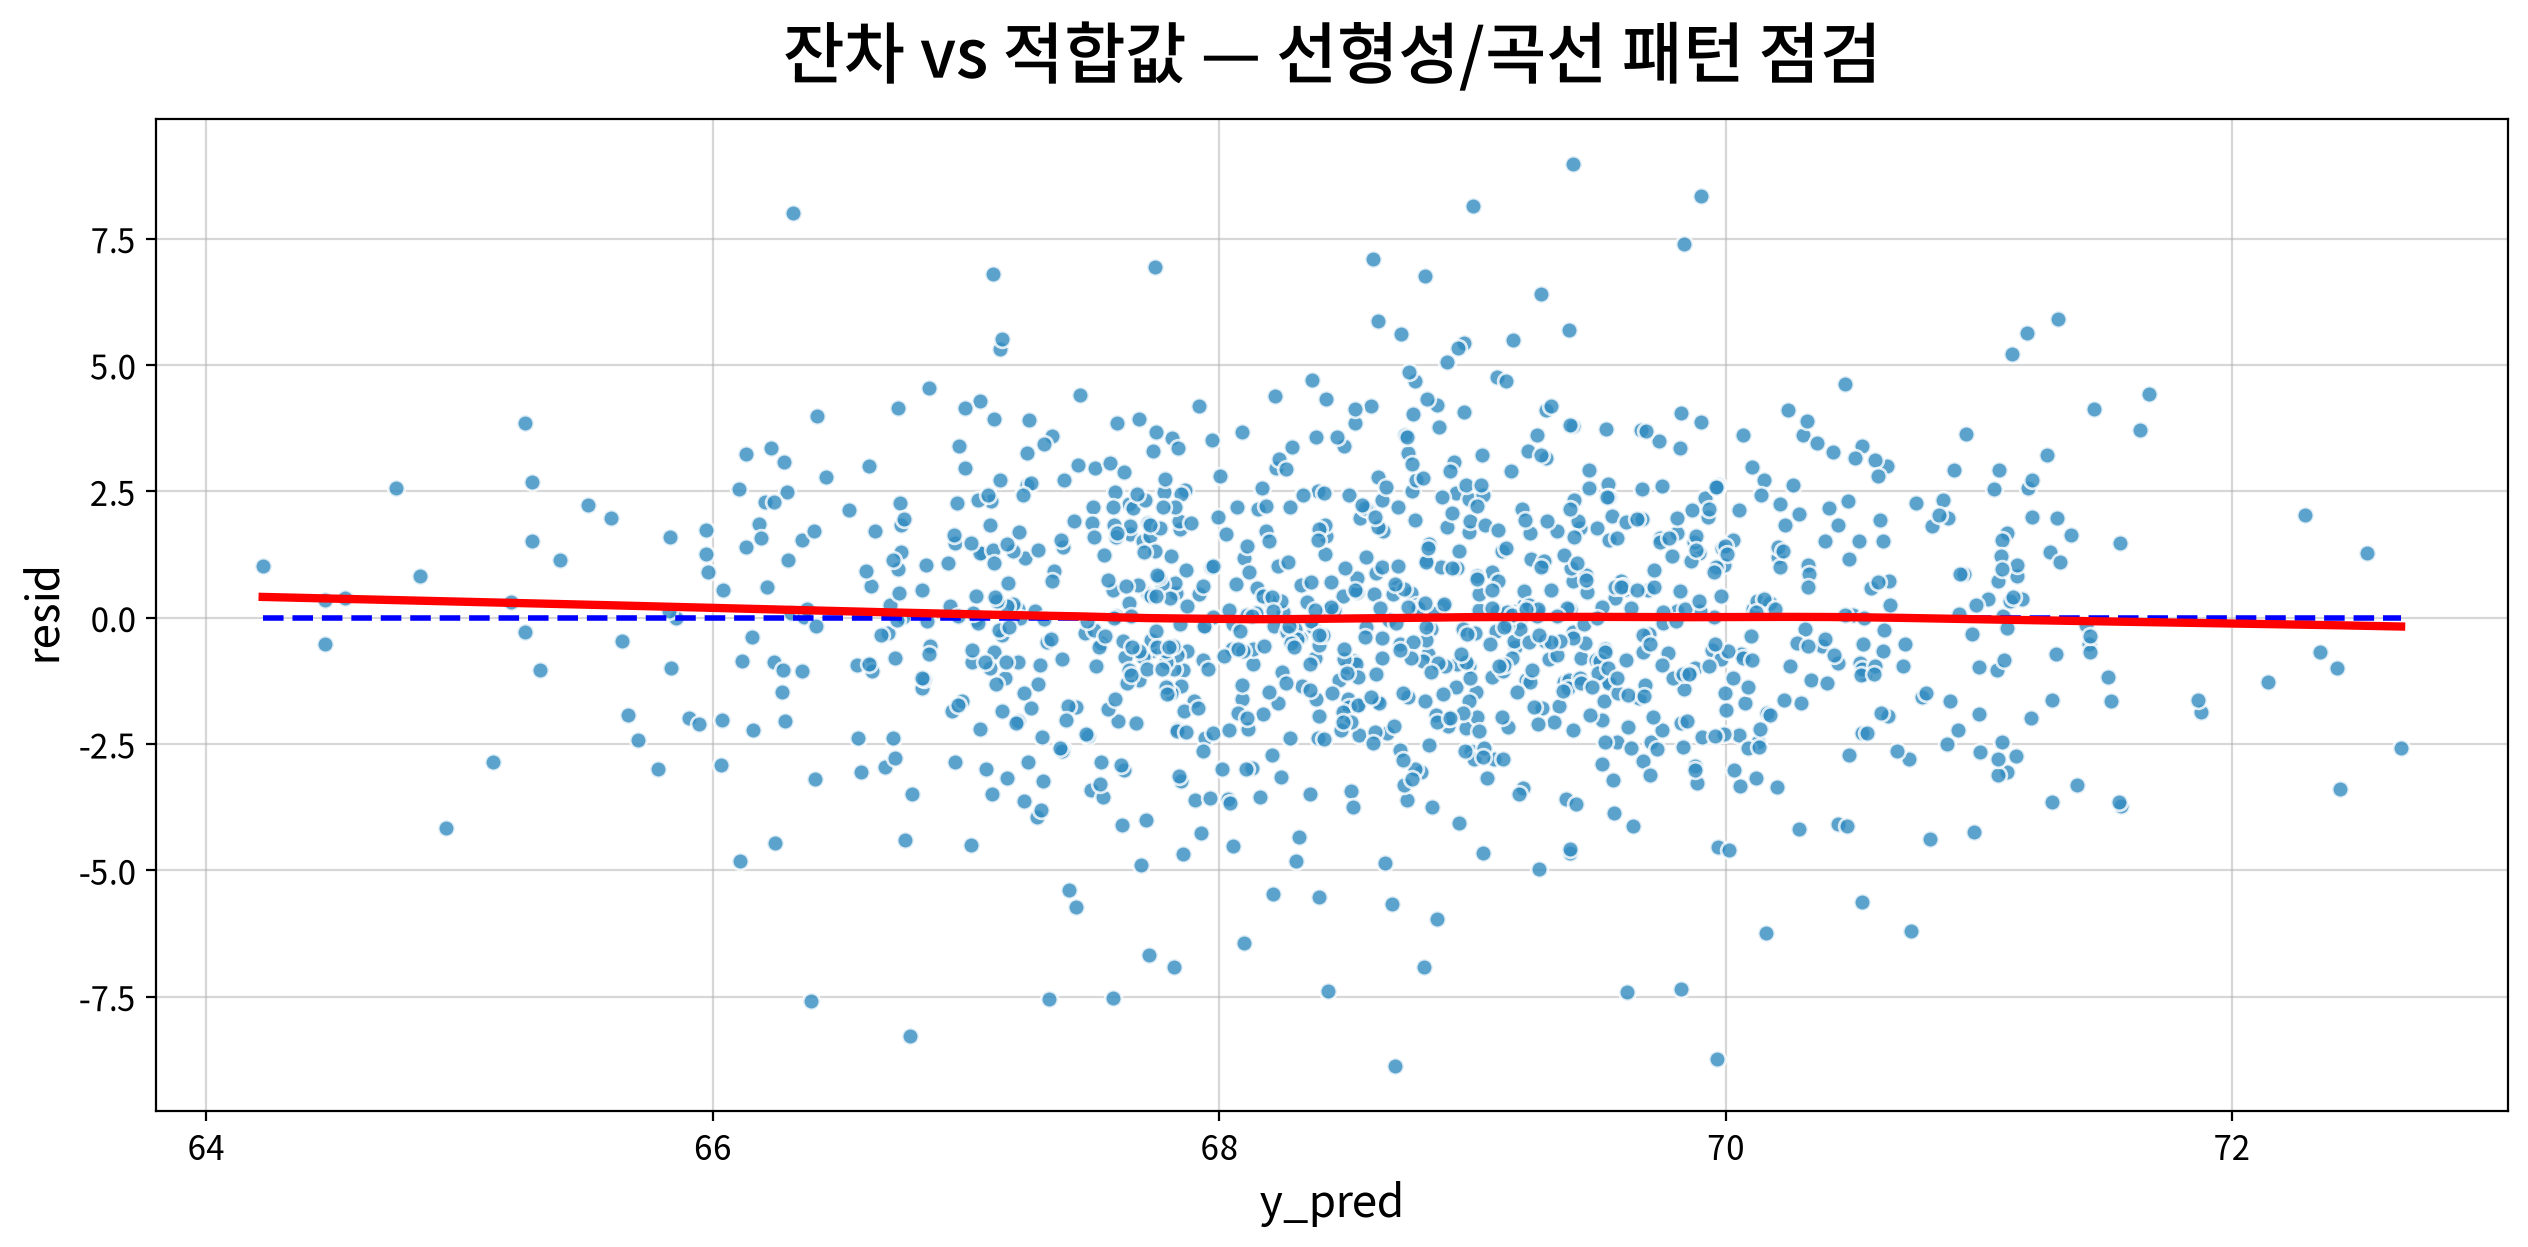

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,0.003,0.960,0.003,0.960,True,귀무가설 채택 → 등분산성 만족


In [4]:
# (1) 선형성 — 잔차 vs 적합값 산점도(곡선 패턴 확인) + Ramsey RESET 검정
my_ols.test_linear(fit, title="잔차 vs 적합값 — 선형성/곡선 패턴 점검")

# (2) 등분산성 — Breusch-Pagan 검정 (깔때기 모양의 통계적 뒷받침)
my_ols.test_equalvar(fit)

#### 💡인사이트

- 잔차 산점도에서 점들이 0을 중심으로 위아래 고르게 흩어져 있고, 곡선 패턴이나 깔때기(부채꼴) 모양이 나타나지 않는다.
- 선형성: Ramsey RESET 검정의 p값이 약 0.86으로 0.05보다 크므로, 직선으로 설명하지 못한 곡선 관계가 남아 있지 않다(선형성 충족).
- 등분산성: Breusch-Pagan 검정의 F 검정 p값이 약 0.96으로 0.05보다 크므로, 적합값이 커져도 잔차의 분산이 일정하게 유지된다(등분산성 충족).

### Mission 3. 잔차는 종을 닮았는가 — 정규성

잔차의 Q-Q plot을 그려 점들이 기준선에서 벗어나는 구간이 있는지 관찰하라.

Shapiro-Wilk 검정을 수행하고, p-value를 근거로 정규성 성립 여부를 결론지어라(Shapiro-Wilk를 사용할 수 없다면 K-S검정으로 선회).

,statistic,p-value,normality,result
Kolmogorov-Smirnov,0.022,0.667,True,귀무가설 채택 → 정규성 만족


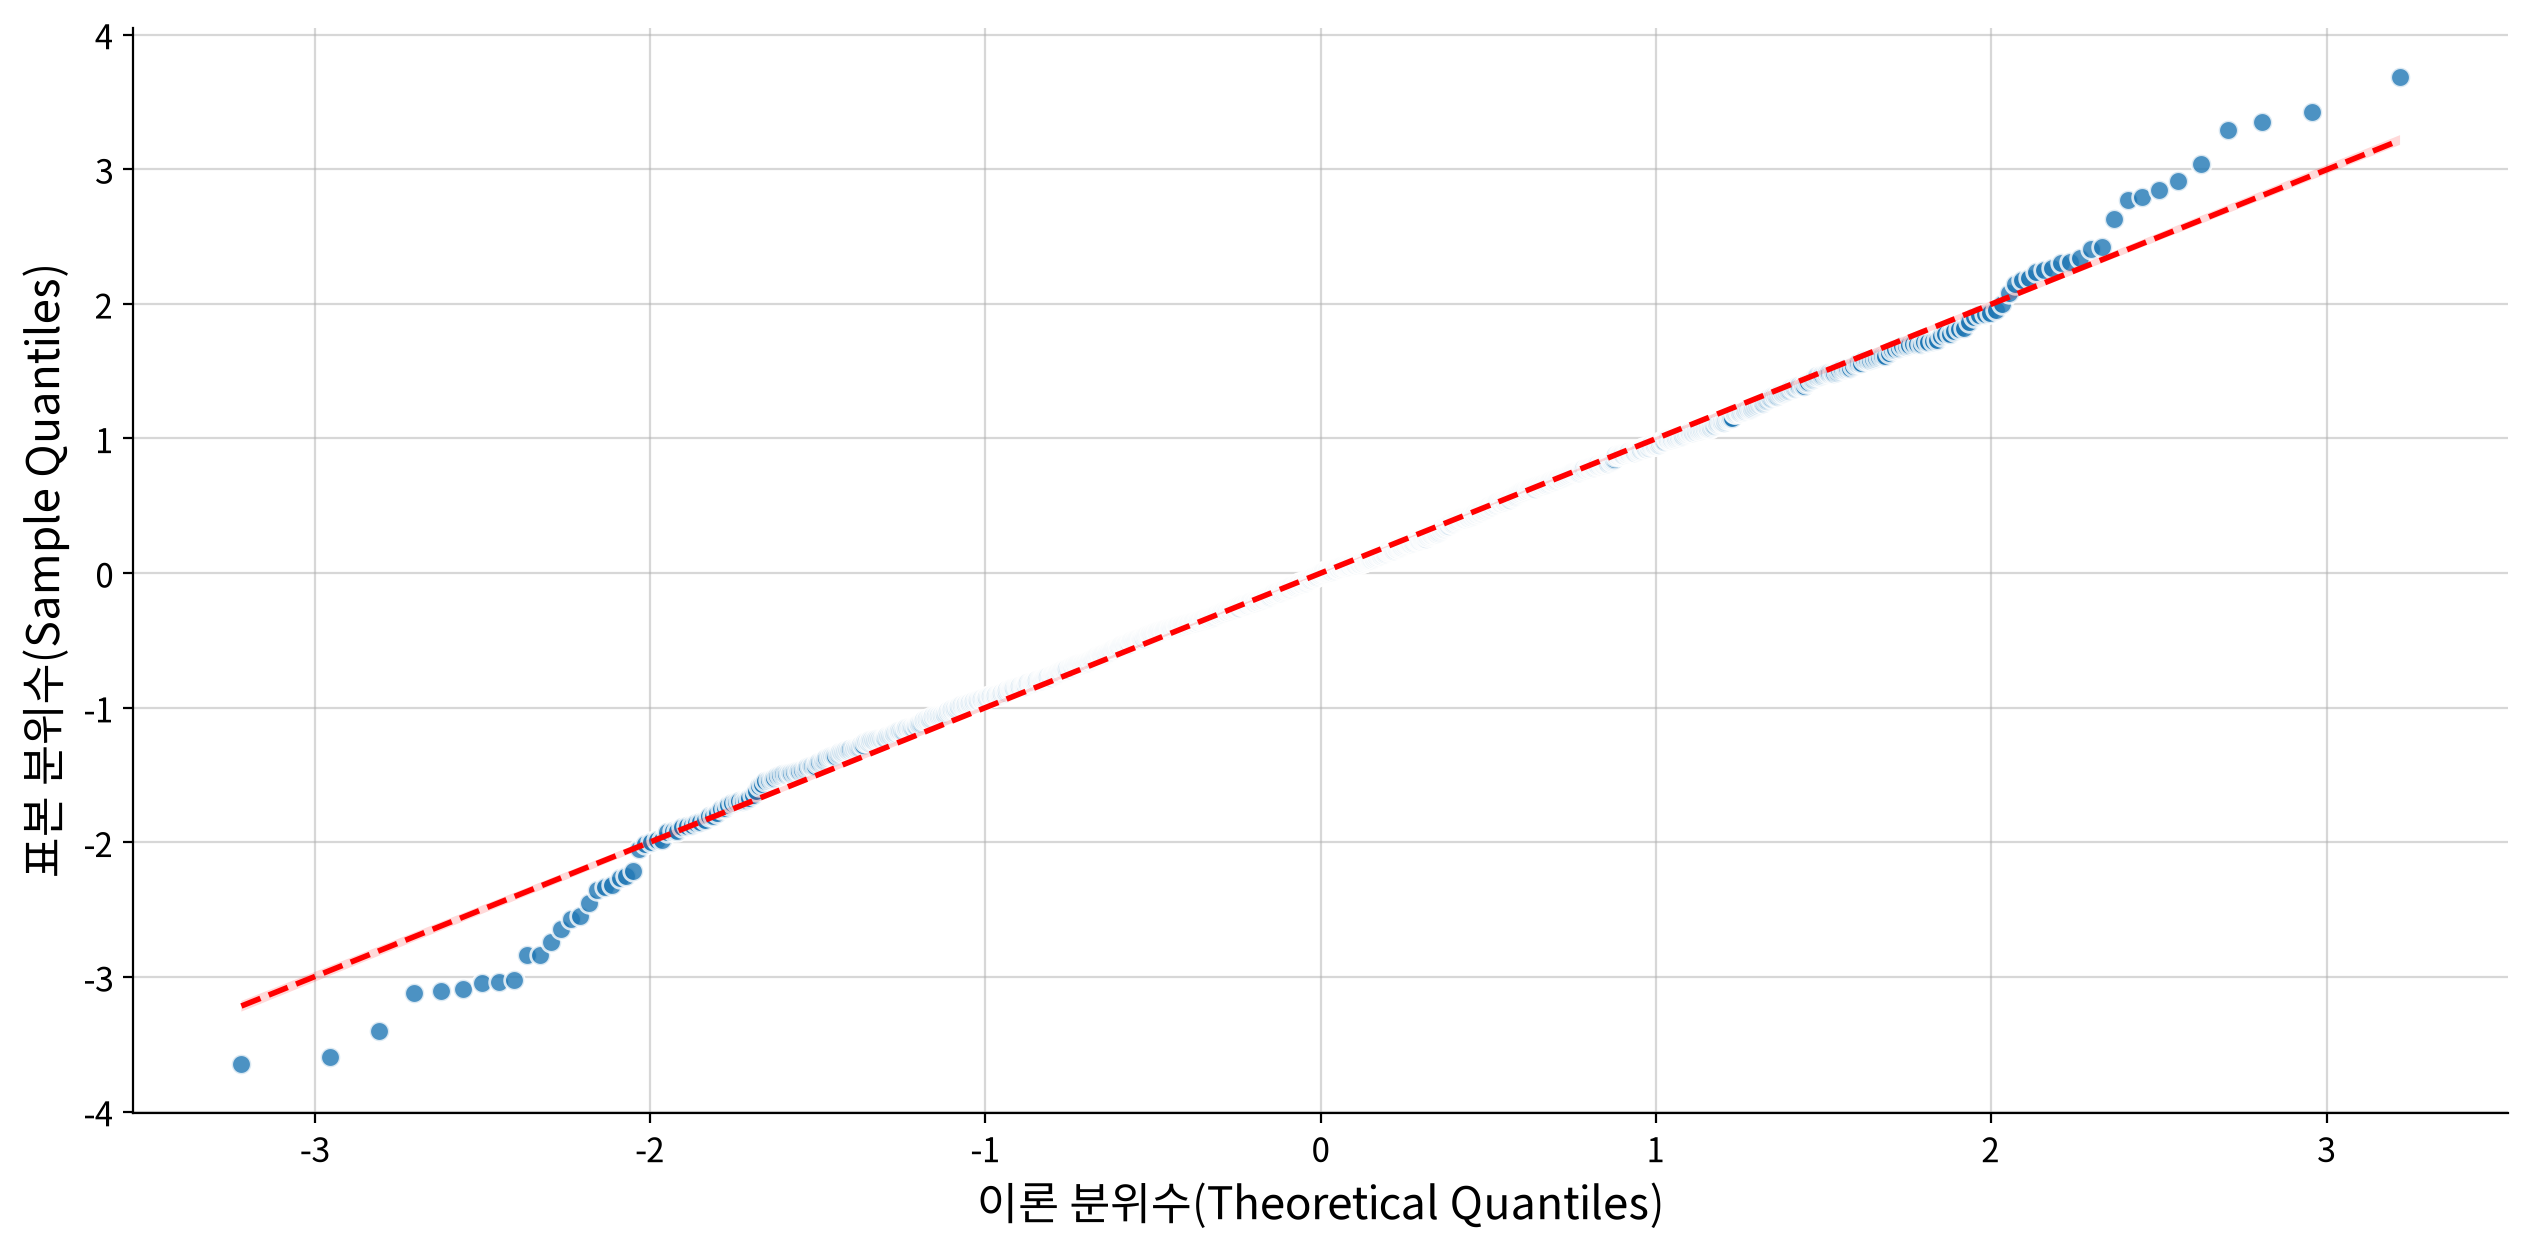

,기대(%),허용범위(%),실제(%),판정
구간,,,,
±1√MSE,68.000,65~71,71.430,위배
±2√MSE,95.000,94~96,95.730,충족
±3√MSE,99.700,99~100,98.700,위배


√MSE = 2.44 · 구간 규칙 판정: 정규성 위배


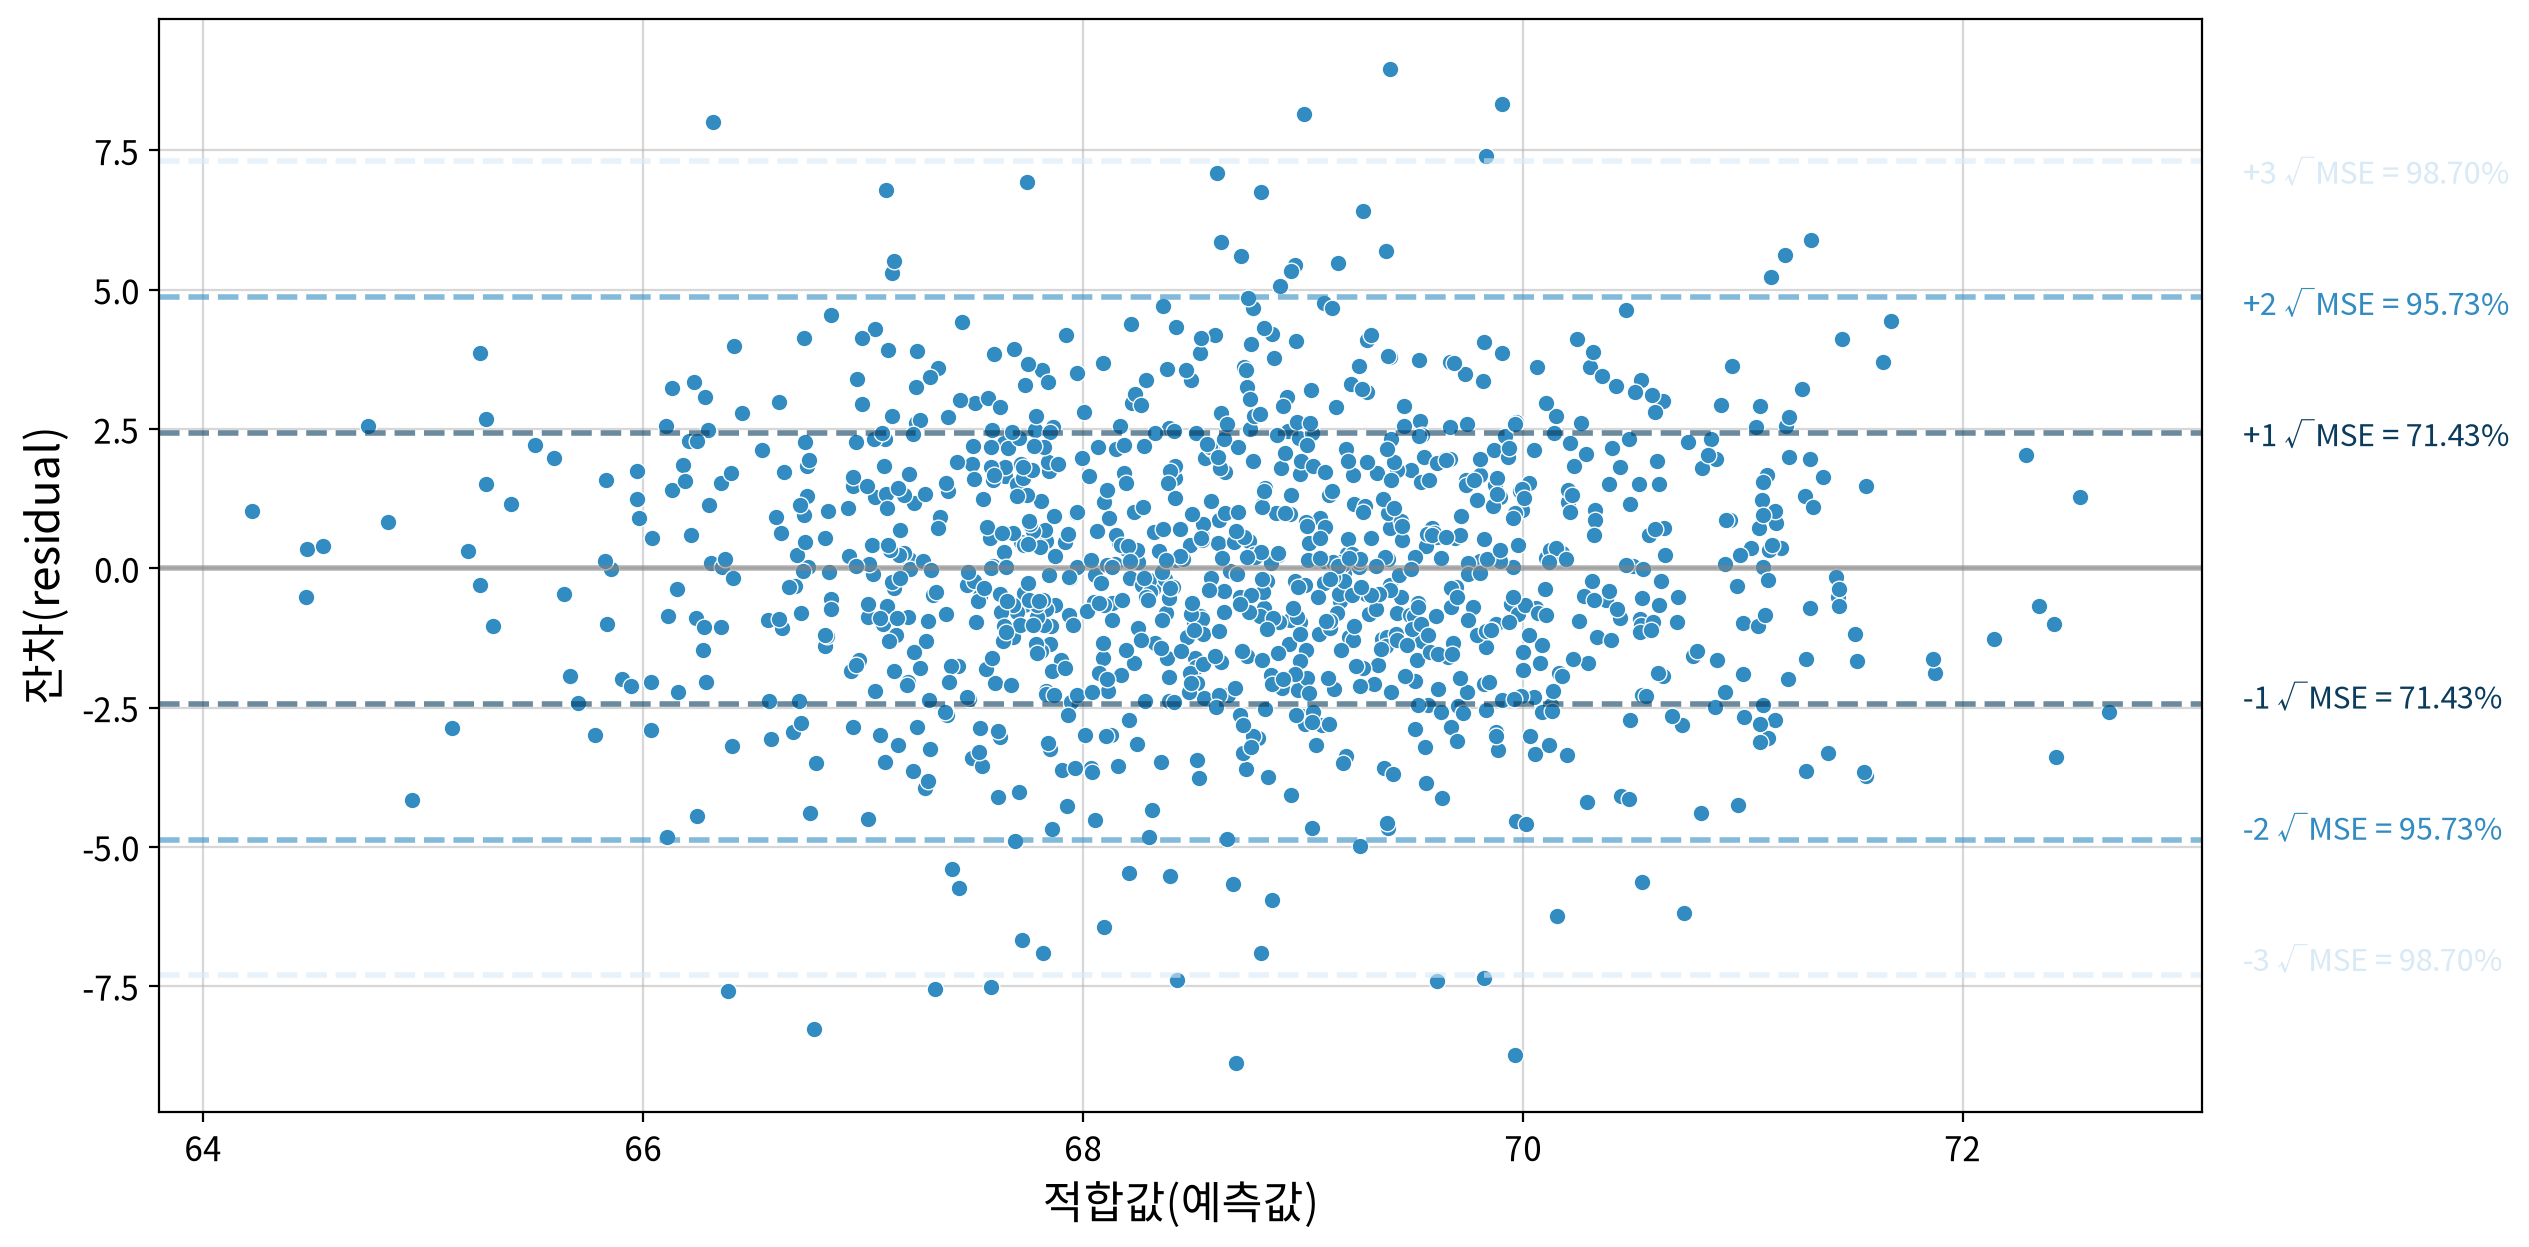

In [5]:
# 잔차의 정규성 — Q-Q plot + 정규성 검정
# 함수는 표본 수 규칙에 따라 n<30이면 Shapiro-Wilk, n>=30이면 K-S를 자동 선택한다.
my_ols.test_normal(fit)

#### 💡인사이트

- 표본 수가 1,078개로 많아, 작은 차이에도 쉽게 정규성을 기각하는 Shapiro-Wilk 대신, 함수가 규칙(표본 수 30개 이상)에 따라 Kolmogorov-Smirnov 검정으로 자동 전환했다.
- Kolmogorov-Smirnov 검정의 p값이 약 0.67로 0.05보다 크므로, 잔차가 정규분포를 따른다고 본다(정규성 충족).
- Q-Q plot의 점들도 기준선을 대체로 잘 따라가며, 양쪽 끝 꼬리 부분에서만 조금 벗어난다.
- ±1·±2·±3√MSE 구간의 68-95-99.7 규칙 표에서는 일부 구간이 위배로 표시되지만, 이는 참고용 보조 지표이므로 정식 검정인 Kolmogorov-Smirnov 결과를 우선한다.

### Mission 4. 심사위원에게 답하라 — 독립성과 종합 판정

Durbin-Watson 통계량으로 잔차의 독립성을 확인하라.

네 가지 가정의 진단 결과를 종합해, 심사위원을 설득할 결론을 한 문단으로 작성하라

In [6]:
# 잔차의 독립성 — Durbin-Watson 통계량
my_ols.test_independent(fit)

,statistic,independence,result
Durbin-Watson,0.766,False,독립성 위반 (양(+)의 자기상관)


#### 💡인사이트

- Durbin-Watson 통계량이 약 0.77로 1.5보다 작아, 통계량만 보면 양(+)의 자기상관이 있어 독립성이 위반된 것으로 나온다.
- 하지만 Durbin-Watson은 시간 순서가 있는 시계열 데이터를 위한 지표다. father-son 데이터는 서로 다른 아버지·아들 쌍을 모은 자료로 시간 순서가 없으므로, 이 자기상관 신호는 실제 문제로 보지 않고 무시해도 된다.
- 종합하면 선형성(RESET p 약 0.86), 등분산성(Breusch-Pagan p 약 0.96), 정규성(K-S p 약 0.67)의 세 가지 핵심 가정이 모두 충족되었다.
- 독립성만 통계량상 위반으로 나왔으나 자료의 성격상 적용 대상이 아니므로, 이 단순선형회귀 모형은 가정을 실질적으로 만족하며 회귀계수의 추정과 유의성 검정 결과를 신뢰할 수 있다.